# Overview
The following dataset comes from a beijing dataset from the UCI repository. The dataset includes the pollution in the air over time. There are multiple stations where data was collected but we chose the Aotizhongxin station. Contains 35k+ datapoints.

**Target**: PM2.5 / PM10, which are fine and coarse particulate matter such as smoke and dust.

Chemical Pollutants:
- SO2: Sulfer Dioxide
- NO2: Nitrogen Dioxide (vehicle emission)
- CO: Carbon Monoxide
- O3: Ground level ozone

Weather:
- TEMP: Temperature
- PRES: Precipitation
- DEWP: Dew Point Temp (Measure of Moisture)
- RAIN: Amount of rainfall
- wd: wind direction
- WSPM: Wind Speed (meters/sec)

In [8]:
import pandas as pd
import numpy as np
import io
import requests
import zipfile

# Download main zip
url = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
r = requests.get(url)
outer_zip = zipfile.ZipFile(io.BytesIO(r.content))

# Extract inner zip
inner_zip_name = 'PRSA2017_Data_20130301-20170228.zip'
with outer_zip.open(inner_zip_name) as inner_zip_data:
    inner_zip_bytes = io.BytesIO(inner_zip_data.read())
    z = zipfile.ZipFile(inner_zip_bytes)

# Access the station CSV
csv_name = 'PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv'
with z.open(csv_name) as f:
    df = pd.read_csv(f)

# Cleaning and Interpolation

In [9]:
# --- Cleaning logic ---
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)
df = df.drop(columns=['No', 'year', 'month', 'day', 'hour', 'station'])

# Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for continuous timeline
# We expect exactly 1 hour between every row.
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_hours = len(expected_range) - len(df)
print(f"Missing hours in timeline: {missing_hours}")

# Interpolate to fill the gaps
df = df.interpolate(method='linear').ffill().bfill()

# Summary Statistics
print(df.describe())

Duplicate rows: 0
Missing hours in timeline: 0
              PM2.5          PM10           SO2           NO2            CO  \
count  35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
mean      82.540623    110.210033     17.459251     59.074106   1264.692405   
std       81.956401     95.262531     22.702284     37.000918   1239.411826   
min        3.000000      2.000000      0.285600      2.000000    100.000000   
25%       22.000000     38.000000      3.000000     30.000000    500.000000   
50%       58.000000     87.000000      9.000000     53.000000    900.000000   
75%      114.000000    154.000000     22.000000     81.000000   1500.000000   
max      898.000000    984.000000    341.000000    290.000000  10000.000000   

                 O3          TEMP          PRES          DEWP          RAIN  \
count  35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
mean      55.328626     13.581414   1011.851650      3.120296      0.067383   
std 

/tmp/ipykernel_438/4063287299.py:17: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').ffill().bfill()


# Exploratory Data Analysis

Include visualization of the loss function

In [10]:
df.isnull().sum()

,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0
DEWP,0
RAIN,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   35064 non-null  float64
 1   PM10    35064 non-null  float64
 2   SO2     35064 non-null  float64
 3   NO2     35064 non-null  float64
 4   CO      35064 non-null  float64
 5   O3      35064 non-null  float64
 6   TEMP    35064 non-null  float64
 7   PRES    35064 non-null  float64
 8   DEWP    35064 non-null  float64
 9   RAIN    35064 non-null  float64
 10  wd      35064 non-null  object 
 11  WSPM    35064 non-null  float64
dtypes: float64(11), object(1)
memory usage: 4.5+ MB


In [12]:
df.describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,82.540623,110.210033,17.459251,59.074106,1264.692405,55.328626,13.581414,1011.851650,3.120296,0.067383,1.708577
std,81.956401,95.262531,22.702284,37.000918,1239.411826,57.327470,11.400426,10.404517,13.690314,0.909798,1.204180
min,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,58.000000,87.000000,9.000000,53.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,114.000000,154.000000,22.000000,81.000000,1500.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


''

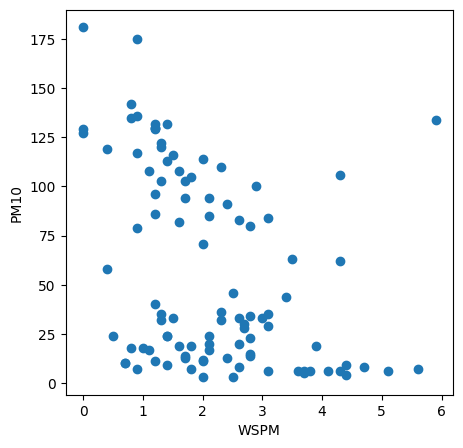

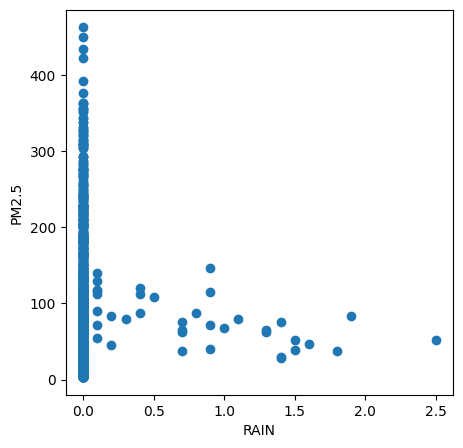

In [13]:
import matplotlib.pyplot as plt

x_axis = "WSPM"
y_axis = "PM10"

# useful for identifying relationship (i.e. correlation) between two parameters
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(df[x_axis][0:100], df[y_axis][0:100])
ax.set_xlabel(x_axis)
ax.set_ylabel(y_axis)
,

x_axis = "RAIN"
y_axis = "PM2.5"

# useful for identifying relationship (i.e. correlation) between two parameters
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(df[x_axis][0:1000], df[y_axis][0:1000])
ax.set_xlabel(x_axis)
ax.set_ylabel(y_axis)
,

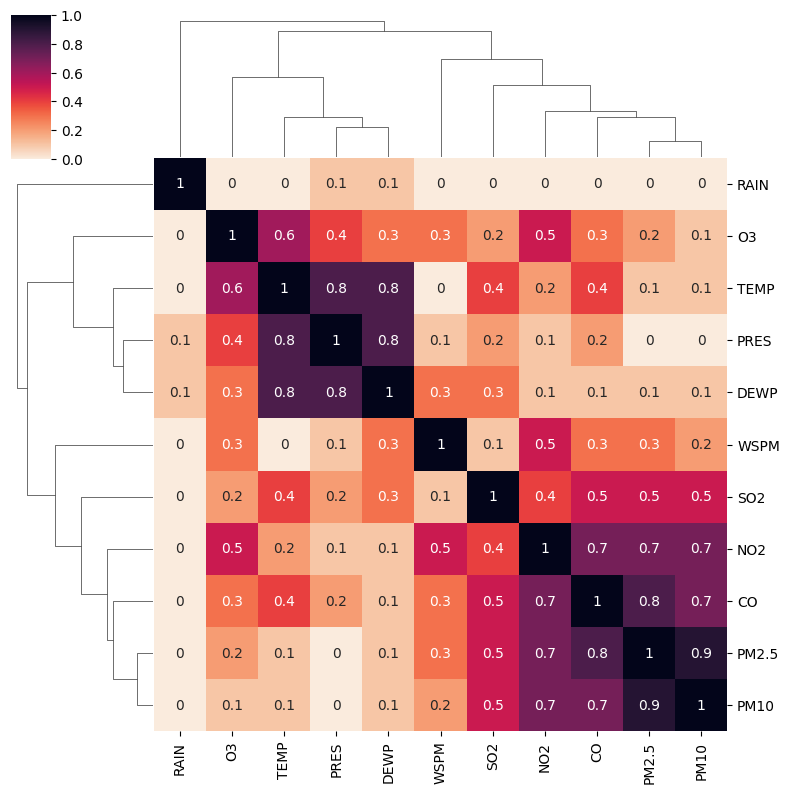

In [14]:
import seaborn as sns

# Heatmap with clustering
g = sns.clustermap(df.corr(numeric_only=True).abs().round(1),
                   annot=True,
                   cmap='rocket_r',
                   figsize=(8, 8))

plt.show()

We must drop the columns that are too interconnected and choose between solving for PM10 or PM2.5.

In [15]:
# Drop PM10 and DEWP
df = df.drop(columns=['PM10', 'DEWP'])

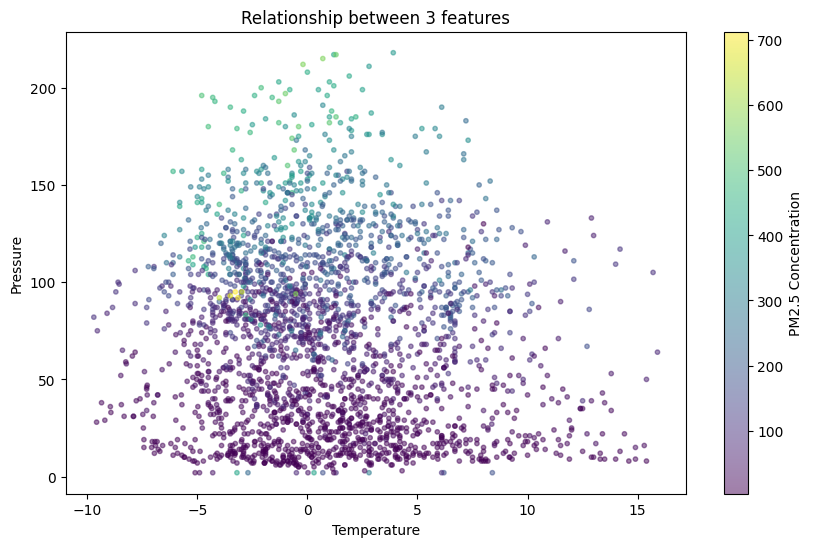

In [16]:
# We pick two high-impact features to compare against each other,
# while using color to show the PM2.5 intensity.
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['TEMP'][-2500:], df['NO2'][-2500:],
                      c=df['PM2.5'][-2500:],  # Use color for the target
                      cmap='viridis',
                      alpha=0.5,
                      s=10) # Smaller dots for 35,000 points

plt.colorbar(label='PM2.5 Concentration')
plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.title('Relationship between 3 features')
plt.show()

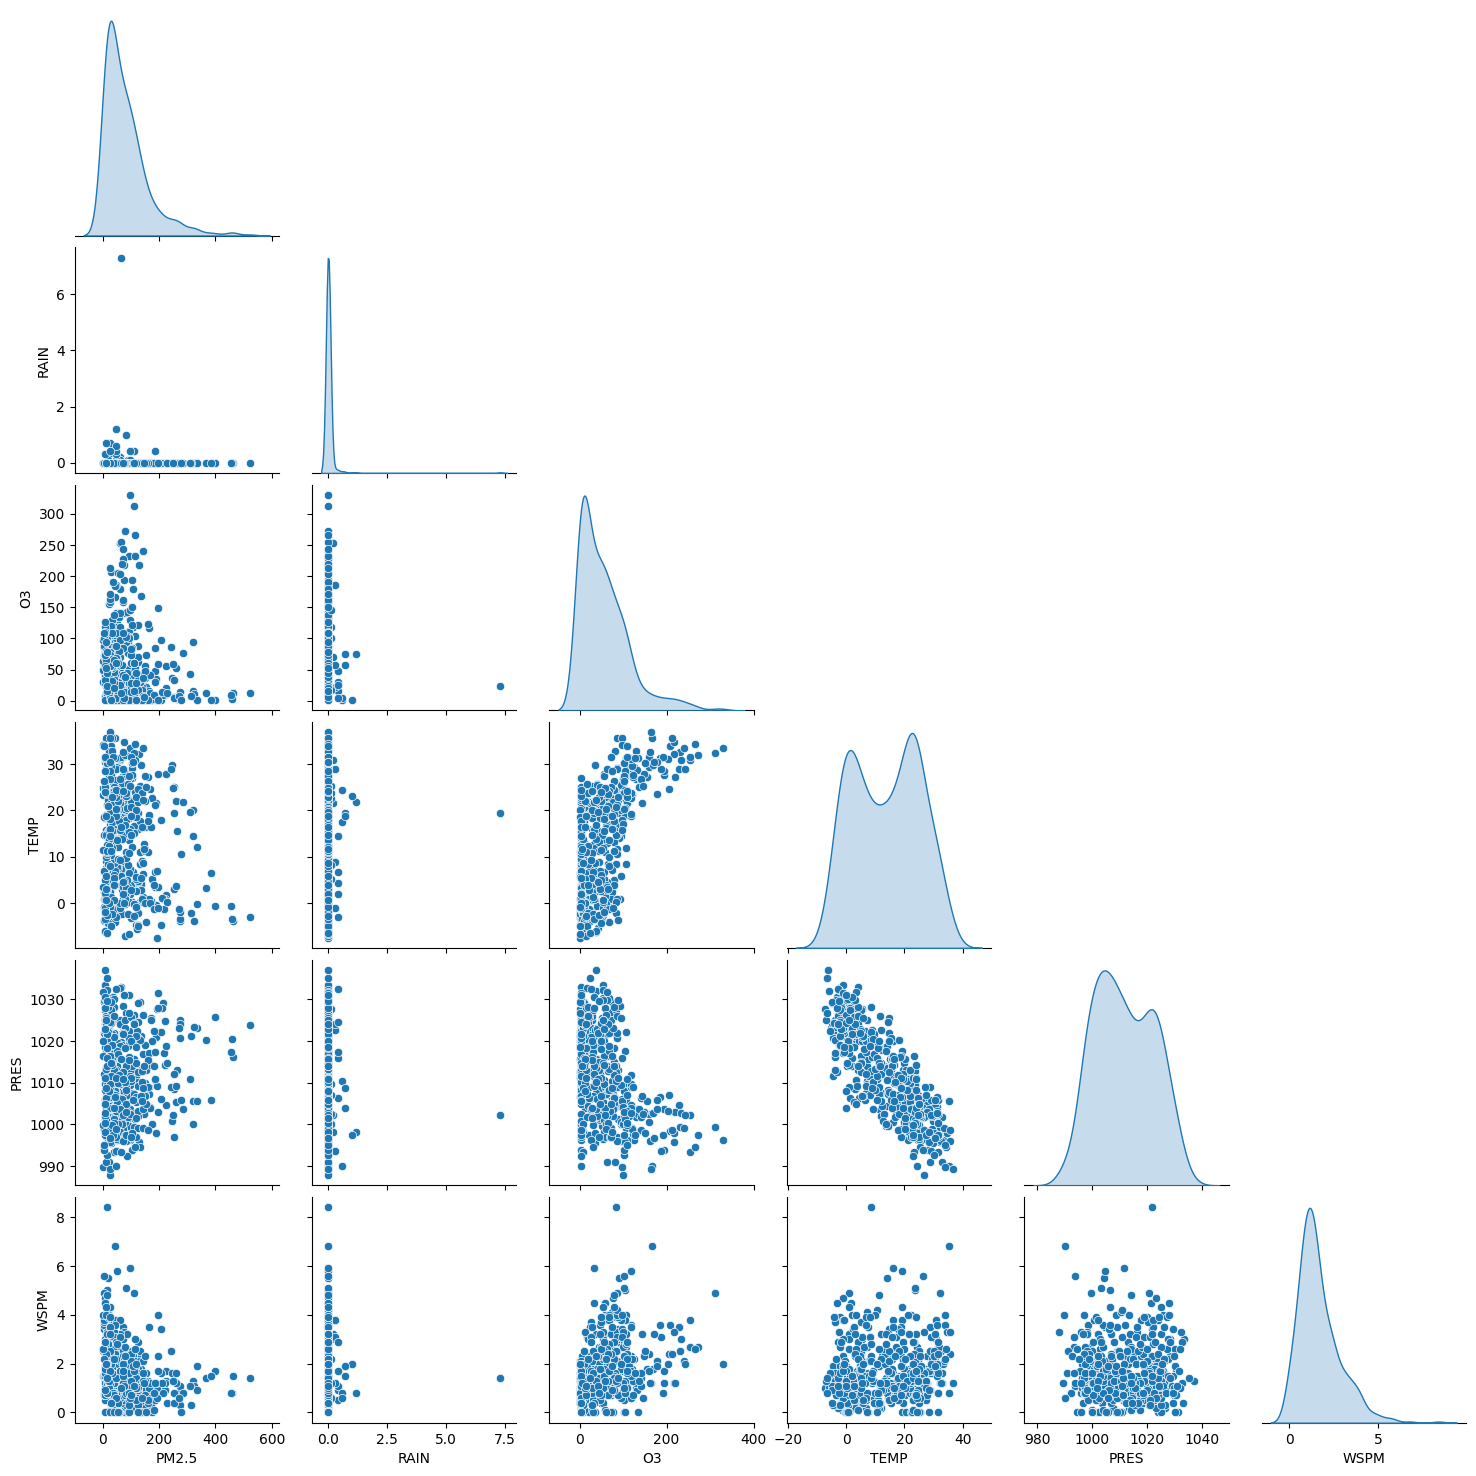

In [17]:
# Add PM2.5 to the list so it gets its own row/column in the grid
plot_features = ['PM2.5', 'RAIN', 'O3', 'TEMP', 'PRES', 'WSPM']

sns.pairplot(df[plot_features].sample(500),
             diag_kind='kde',
             corner=True) # Corner=True makes it much cleaner to read
plt.show()

# Feature Engineering

In [18]:
# Temporal Cyclical Features
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# Wind Direction (wd) Mapping
wd_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

# Apply the map and create cyclical features
df['wd_deg'] = df['wd'].map(wd_map)
df['wd_sin'] = np.sin(2 * np.pi * df['wd_deg'] / 360)
df['wd_cos'] = np.cos(2 * np.pi * df['wd_deg'] / 360)

# Drop all non-numeric columns
# We drop 'wd' (the string) and 'wd_deg' (the intermediate degree number)
df = df.drop(columns=['wd', 'wd_deg'])

### Normalizing The Features

In [19]:
# Scalar
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

# Data Split and Windows

In [20]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def create_sequences(data_values, seq_length):
    xs, ys = [], []
    for i in range(len(data_values) - seq_length):
        # X: Use all columns EXCEPT index 0 (PM2.5)
        x = data_values[i:(i + seq_length), 1:]
        # y: Use index 0 (PM2.5) at the next hour
        y = data_values[i + seq_length, 0]
        xs.append(x)
        ys.append(y)
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

# Parameters
SEQ_LENGTH = 24
BATCH_SIZE = 64

# Split scaled data (80% Train, 20% Test)
train_size = int(len(df_scaled) * 0.8)
train_df = df_scaled.iloc[:train_size].values
test_df = df_scaled.iloc[train_size:].values

X_train, y_train = create_sequences(train_df, SEQ_LENGTH)
X_test, y_test = create_sequences(test_df, SEQ_LENGTH)

# Create Loaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"X_train shape: {X_train.shape}") # [Samples, 24, 15]
print(df.columns)

X_train shape: torch.Size([28027, 24, 14])
Index(['PM2.5', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'RAIN', 'WSPM',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wd_sin', 'wd_cos'],
      dtype='object')


# Prepare the model

In [5]:
import torch.nn as nn

class SimpleRNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super(SimpleRNN, self).__init__() # automatically tracks all weights and biases
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # RNN Layer
    # batch_first=True makes the input (Batch, Sequence, Features)
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

    # Fully connected output layer
    self.fc = nn.Linear(hidden_size, output_size) # hidden -> output

  def forward(self, x): # x is
    # Initialize hidden state with 0s
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device) # ensure same GPU

    # Forward pass: output contains the hidden states for all 24 time steps
    output, _ = self.rnn(x, h0)

    return self.fc(output[:, -1, :])


In [7]:
import torch
import torch.optim as optim

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleRNN(input_size=14, hidden_size=64, output_size=1).to(device)

# MSE is sensitive to outliers (pollution spikes), which is good for air quality
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [16]:
epochs = 50
history = {'train_loss': [], 'test_loss': []}

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Validation/Testing Phase ---
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            test_loss += loss.item()

    # Record history
    avg_train = train_loss/len(train_loader)
    avg_test = test_loss/len(test_loader)
    history['train_loss'].append(avg_train)
    history['test_loss'].append(avg_test)

    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.6f} | Test Loss: {avg_test:.6f}')

Epoch [5/50] | Train Loss: 0.002546 | Test Loss: 0.002553
Epoch [10/50] | Train Loss: 0.002319 | Test Loss: 0.001954
Epoch [15/50] | Train Loss: 0.002228 | Test Loss: 0.002255
Epoch [20/50] | Train Loss: 0.002107 | Test Loss: 0.001990
Epoch [25/50] | Train Loss: 0.002012 | Test Loss: 0.001896
Epoch [30/50] | Train Loss: 0.001952 | Test Loss: 0.002014
Epoch [35/50] | Train Loss: 0.001921 | Test Loss: 0.002295
Epoch [40/50] | Train Loss: 0.001846 | Test Loss: 0.001942
Epoch [45/50] | Train Loss: 0.001789 | Test Loss: 0.002064
Epoch [50/50] | Train Loss: 0.001708 | Test Loss: 0.002390


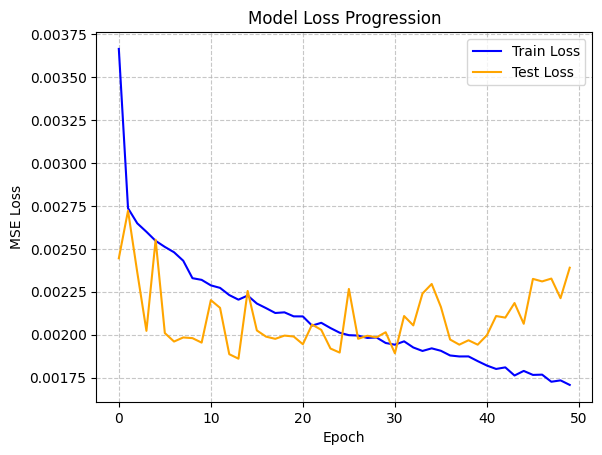

In [17]:
# Plot the lines
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['test_loss'], label='Test Loss', color='orange')

# Add labels and title
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.7)

# Show legend and plot
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, test_loader, scaler, device):
    model.eval()
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            preds = model(batch_X)
            all_preds.extend(preds.cpu().numpy())
            all_actuals.extend(batch_y.numpy())

    # Inverse transform using the stored scaler parameters
    pm25_min = scaler.data_min_[0]
    pm25_max = scaler.data_max_[0]

    actuals_real = np.array(all_actuals) * (pm25_max - pm25_min) + pm25_min
    preds_real = np.array(all_preds).flatten() * (pm25_max - pm25_min) + pm25_min

    # Metric Calculations
    mae = mean_absolute_error(actuals_real, preds_real)
    rmse = np.sqrt(mean_squared_error(actuals_real, preds_real))
    r2 = r2_score(actuals_real, preds_real)

    # Directional Accuracy
    actual_change = np.diff(actuals_real) > 0
    pred_change = np.diff(preds_real) > 0
    dir_acc = np.mean(actual_change == pred_change) * 100

    # Print Results
    print(f"--- Model Evaluation Results ---")
    print(f"MAE:      {mae:.2f} ug/m3")
    print(f"RMSE:     {rmse:.2f} ug/m3")
    print(f"R2 Score: {r2:.4f}")
    print(f"Dir Acc:  {dir_acc:.2f}%")

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "dir_acc": dir_acc,
        "actuals": actuals_real,
        "preds": preds_real
    }

# Usage:
rnn_results = evaluate_model(model, test_loader, scaler, device)

--- Model Evaluation Results ---
MAE:      103.44 ug/m3
RMSE:     120.51 ug/m3
R2 Score: -1.0734
Dir Acc:  48.90%


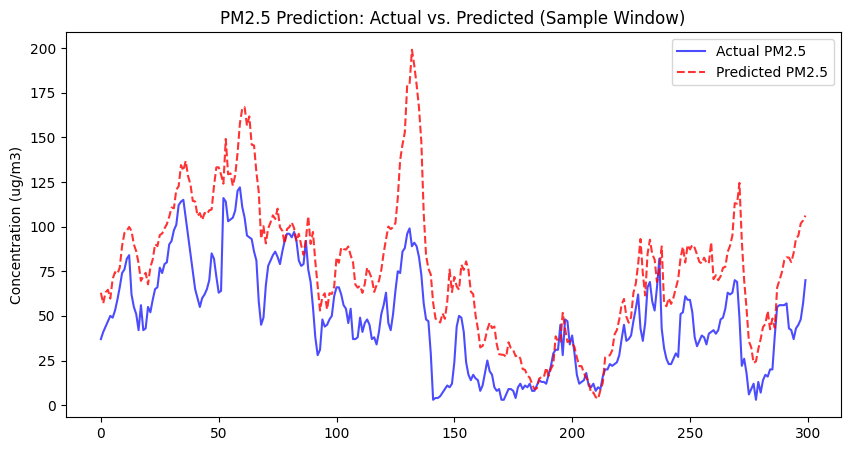

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_results["actuals"][100:400], label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(rnn_results["preds"][100:400], label='Predicted PM2.5', color='red', linestyle='--', alpha=0.8)
plt.title('PM2.5 Prediction: Actual vs. Predicted (Sample Window)')
plt.ylabel('Concentration (ug/m3)')
plt.legend()
plt.show()

## Logging Results
**Initial Parameters:**
- lr=0.001
- input_size=14
- hidden_size=64
- output_size=1\

Mean Absolute Error: 97.17 ug/m3\
Root Mean Squared Error: 140.23 ug/m3

---
**Increased hidden_size to 128:**\
Mean Absolute Error: 25.01 ug/m3\
Root Mean Squared Error: 39.78 ug/m3\
R2 Score: 0.7741\
Directional Accuracy: 59.87%

---
**Increased Epochs to 50 and decreased learning rate to 0.0005:**\
MAE:      26.97 ug/m3\
RMSE:     42.40 ug/m3\
R2 Score: 0.7433\
Dir Acc:  59.47%

---
**Brought hidden_size back to 64:**\
MAE:      26.86 ug/m3\
RMSE:     42.77 ug/m3\
R2 Score: 0.7389\
Dir Acc:  59.62%

---
MSE was greatly improved by increasing hidden layer size or epochs. When both improvements were combined, the improved performance was negligible.

# LSTM and GRU

In [21]:
class LSTM_AirModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Hidden states: h0 (short term) and c0 (long term)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

# Initialize and train
lstm_model = LSTM_AirModel(input_size=14, hidden_size=128, output_size=1).to(device)

In [22]:
class GRU_AirModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(GRU_AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, hn = self.gru(x, h0)
        return self.fc(out[:, -1, :])

gru_model = GRU_AirModel(input_size=14, hidden_size=128, output_size=1).to(device)

In [23]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=50):
    history = {'train_loss': [], 'test_loss': []}

    print(f"Starting training for {type(model).__name__}...")

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- Validation/Testing Phase ---
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs.squeeze(), batch_y)
                test_loss += loss.item()

        # Record history
        avg_train = train_loss / len(train_loader)
        avg_test = test_loss / len(test_loader)
        history['train_loss'].append(avg_train)
        history['test_loss'].append(avg_test)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.6f} | Test Loss: {avg_test:.6f}')

    return history

# LSTM Run

In [23]:
# Initialize
model_lstm = LSTM_AirModel(14, 128, 1).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Train
history_lstm = train_model(model_lstm, train_loader, test_loader, criterion, optimizer_lstm, device, epochs=50)

# Evaluate using our previous function
lstm_results = evaluate_model(model_lstm, test_loader, scaler, device)

Starting training for LSTM_AirModel...
Epoch [1/50] | Train Loss: 0.003268 | Test Loss: 0.002424
Epoch [5/50] | Train Loss: 0.002036 | Test Loss: 0.002348
Epoch [10/50] | Train Loss: 0.001689 | Test Loss: 0.002279
Epoch [15/50] | Train Loss: 0.001316 | Test Loss: 0.002144
Epoch [20/50] | Train Loss: 0.001082 | Test Loss: 0.002243
Epoch [25/50] | Train Loss: 0.000916 | Test Loss: 0.002643
Epoch [30/50] | Train Loss: 0.000767 | Test Loss: 0.002312
Epoch [35/50] | Train Loss: 0.000626 | Test Loss: 0.002395
Epoch [40/50] | Train Loss: 0.000552 | Test Loss: 0.002356
Epoch [45/50] | Train Loss: 0.000518 | Test Loss: 0.002456
Epoch [50/50] | Train Loss: 0.000453 | Test Loss: 0.002361
--- Model Evaluation Results ---
MAE:      26.60 ug/m3
RMSE:     43.64 ug/m3
R2 Score: 0.7281
Dir Acc:  58.71%


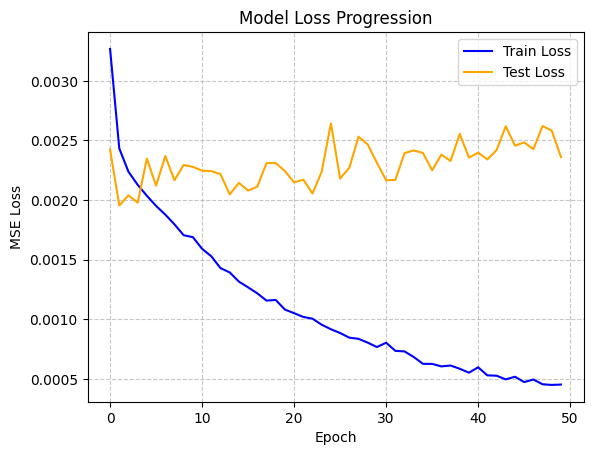

In [24]:
# Plot the lines
plt.plot(history_lstm['train_loss'], label='Train Loss', color='blue')
plt.plot(history_lstm['test_loss'], label='Test Loss', color='orange')

# Add labels and title
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.7)

# Show legend and plot
plt.legend()
plt.show()

# GRU Run

In [27]:
# Initialize
model_gru = GRU_AirModel(14, 128, 1).to(device)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.001)

# Train
history_gru = train_model(model_gru, train_loader, test_loader, criterion, optimizer_gru, device, epochs=50)

# Evaluate
gru_results = evaluate_model(model_gru, test_loader, scaler, device)

Starting training for GRU_AirModel...
Epoch [1/50] | Train Loss: 0.003358 | Test Loss: 0.002123
Epoch [5/50] | Train Loss: 0.002156 | Test Loss: 0.001950
Epoch [10/50] | Train Loss: 0.001724 | Test Loss: 0.002057
Epoch [15/50] | Train Loss: 0.001348 | Test Loss: 0.001984
Epoch [20/50] | Train Loss: 0.001035 | Test Loss: 0.002095
Epoch [25/50] | Train Loss: 0.000807 | Test Loss: 0.002110
Epoch [30/50] | Train Loss: 0.000673 | Test Loss: 0.002296
Epoch [35/50] | Train Loss: 0.000581 | Test Loss: 0.002308
Epoch [40/50] | Train Loss: 0.000466 | Test Loss: 0.002224
Epoch [45/50] | Train Loss: 0.000404 | Test Loss: 0.002244
Epoch [50/50] | Train Loss: 0.000355 | Test Loss: 0.002330
--- Model Evaluation Results ---
MAE:      27.01 ug/m3
RMSE:     43.34 ug/m3
R2 Score: 0.7319
Dir Acc:  58.51%


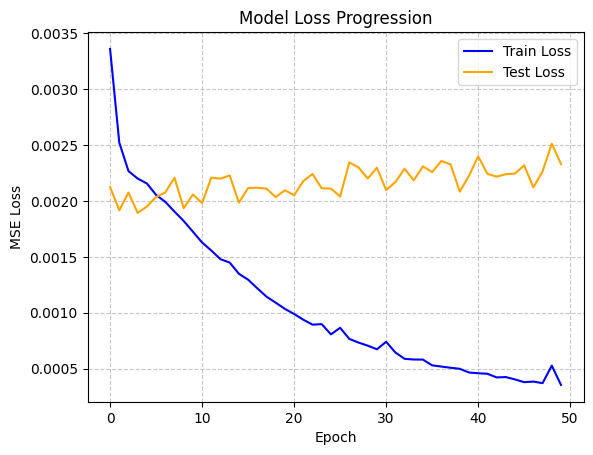

In [28]:
# Plot the lines
plt.plot(history_gru['train_loss'], label='Train Loss', color='blue')
plt.plot(history_gru['test_loss'], label='Test Loss', color='orange')

# Add labels and title
plt.title('Model Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.7)

# Show legend and plot
plt.legend()
plt.show()

# Analysis

Compared to the simple RNN, the training loss of the LSMT and GRU models continued to decrease but we did not see any significant improvements to the test error. The model overfit the data by picking up noise from the train dataset. We also did not see much improvement in overall performance, indicating that increasing model complexity will not solve our problems. We can attempt more feature engineering to increase test performance.



# Implementing With Feed Forward Networks (FFN)

Yes this can be implemented with feed forward networks, but the way the model interprets time will change. The 24 hour periods need to be flattened so that the values at each hour are features.

### Advantages

FFNs are fast and could process the each 24 hour block at once. There is no problem with the model forgetting because there is no recurrence.

### Disadvantages

The network has to process a lot more data at once and it does not make much connection between hours. I.e. the model assumes that hour 1 is unrelated to hour 2, when we know that hour 2 follows 1 and is affected by it. The relationship is learned from scratch, through weights. A RNN uses the same weights for each hour, but a FFN learns new feature weights for each hour in a row.

# Task 3

In [27]:
from transformers import BertModel, BertTokenizer

# Load Pre-trained BERT
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

def get_bert_embedding(word):
    # Tokenize and get hidden states
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the embeddings
    # Uses the mean of the token embeddings for word
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embeddings.numpy()

# Test Input
user_word = input("Enter a word: ")
vector = get_bert_embedding(user_word)
print(f"Embedding for '{user_word}' (Shape {vector.shape}):\n{vector[:5]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Enter a word: hello
Embedding for 'hello' (Shape (768,)):
[-0.15500611  0.09710089 -0.02003918 -0.27376363 -0.23086105]...


# Embedding Choice

BERT was chosen over traditional models. Traditional models like Word2Vec and GloVe assign vectors to words but hold that meaning for the word regardless of the context. The meaning of certain words changes depending on the context its used in, and that is where BERT excels because it generates meaning based on surrounding words.

**Unknown words:**\
Word2Vec and GloVe return errors or zero vectors when an unknown word is presented. BERT breaks the word into known parts to assign it meaning based on those words.

**Training Depth:**\
BERT is trained to predict missing words in a sentence which makes the model learn the way words are used in sentences.

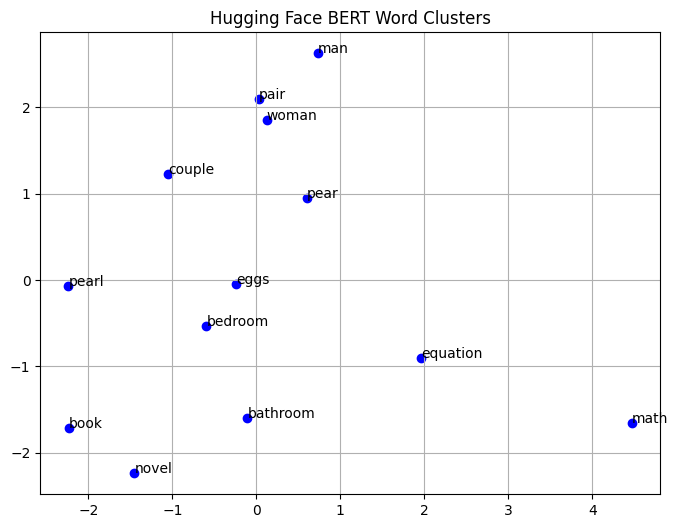

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

def compute_similarity(v1, v2):
    return cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0][0]

# List of words to compare
words = ["book", "novel", "man", "woman", "pear", "pearl", "bedroom", "bathroom", "pair", "couple", "equation", "math", "eggs"]
vectors = [get_bert_embedding(w) for w in words]

# PCA Reduction
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(coords[:, 0], coords[:, 1], c='blue')
for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]))
plt.grid(True)
plt.title("Hugging Face BERT Word Clusters")
plt.show()

# Cosine Similarity

This is helpful because instead of measuring the Euclidean distance between 2 words, measuring the angle in high dimensional spaces gives us a better representation of meaning. Magnitude can correlate to word frequency from training rather then meaning, therefore using the direction for meaning provides a better representation of the words.

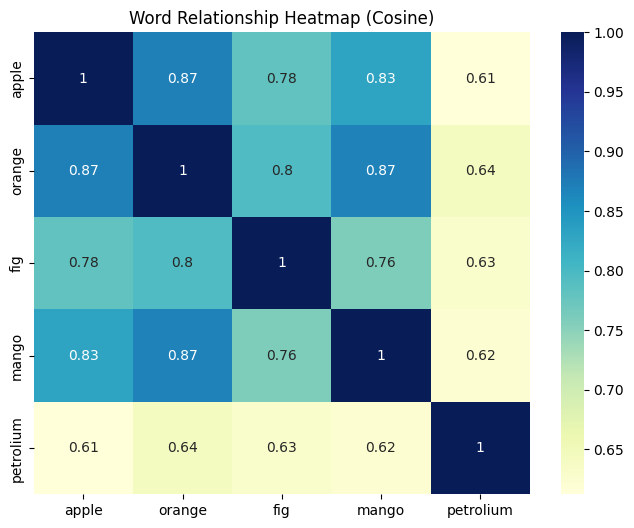

In [29]:
# Custom Dissimilarity Metric Function
def get_score(w1, w2, mode="cosine"):
    v1 = get_bert_embedding(w1)
    v2 = get_bert_embedding(w2)

    if mode == "cosine":
        # Similarity: 1 identical, 0 perpendicular
        return compute_similarity(v1, v2)
    elif mode == "manhattan":
        # Non Similarity: 0 identical, higher is more different
        # torch.dist with p=1 for Manhattan (L1) distance
        return torch.dist(torch.tensor(v1), torch.tensor(v2), p=1).item()

# Heatmap Comparison with Toggle
word_list = ["apple", "orange", "fig", "mango", "petrolium"]
matrix = np.zeros((len(word_list), len(word_list)))

# User choose: "cosine" or "manhattan" metrics
current_mode = "cosine"

for i, x in enumerate(word_list):
    for j, y in enumerate(word_list):
        matrix[i, j] = get_score(x, y, mode=current_mode)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, xticklabels=word_list, yticklabels=word_list,
            annot=True, cmap="YlGnBu")
plt.title(f"Word Relationship Heatmap ({current_mode.capitalize()})")
plt.show()

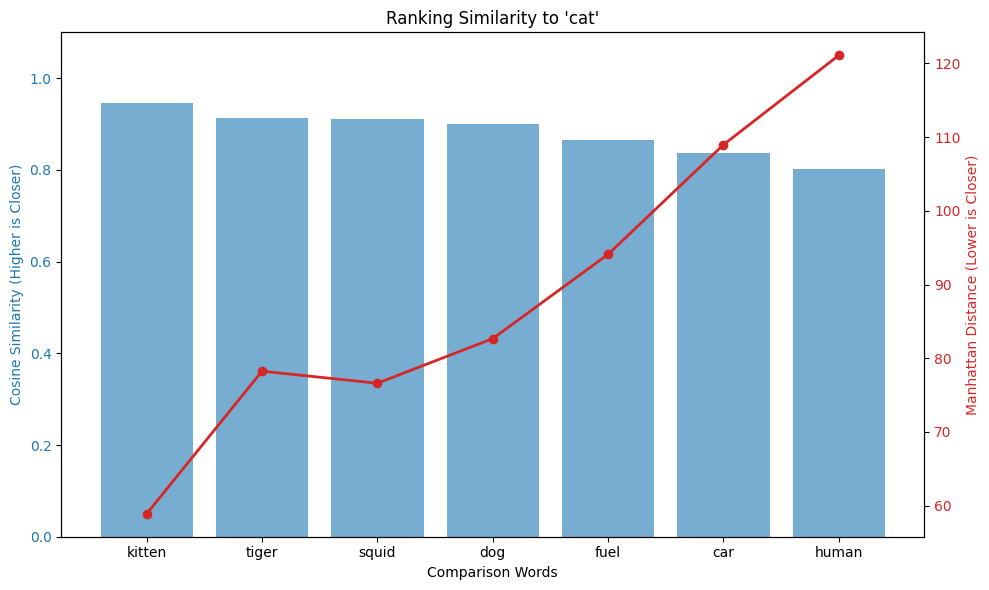

In [30]:
def plot_word_rankings(target_word, comparison_words):
    results = []

    for word in comparison_words:
        # Get both scores
        cos_sim = get_score(target_word, word, mode="cosine")
        man_dist = get_score(target_word, word, mode="manhattan")

        results.append({
            'Word': word,
            'Cosine Similarity': cos_sim,
            'Manhattan Distance': man_dist
        })

    df = pd.DataFrame(results)

    # Sort by Cosine Similarity (Highest to Lowest)
    df = df.sort_values(by='Cosine Similarity', ascending=False)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Cosine Similarity
    color1 = 'tab:blue'
    ax1.set_xlabel('Comparison Words')
    ax1.set_ylabel('Cosine Similarity (Higher is Closer)', color=color1)
    ax1.bar(df['Word'], df['Cosine Similarity'], color=color1, alpha=0.6, label='Cosine')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, 1.1)

    # Manhattan Distance (on a twin axis)
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Manhattan Distance (Lower is Closer)', color=color2)
    ax2.plot(df['Word'], df['Manhattan Distance'], color=color2, marker='o', linewidth=2, label='Manhattan')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title(f"Ranking Similarity to '{target_word}'")
    fig.tight_layout()
    plt.show()

# Run test
test_words = ["dog", "tiger", "kitten", "fuel", "car", "squid", "human"]
plot_word_rankings("cat", test_words)

# Explanation
The metrics used are a Manhattan distance and Cosine Similarity. According to the research done by Aggarwal et. al., the Manhattan distance results in more meaningful and effecient calculations for relationships between word vectors then Euclidean distance or other vector distance calculations. Mikolov et. al. discussed cosine similarity as one of the methods for obtaining meaning from word vectors.  

### References

Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient Estimation of Word Representations in Vector Space. arXiv preprint arXiv:1301.3781.
https://arxiv.org/pdf/1301.3781

Aggarwal, C. C., Hinneburg, A., & Keim, D. A. (2001). On the Surprising Behavior of Distance Metrics in High Dimensional Space. In International Conference on Database Theory (pp. 420-434). Springer.
https://bib.dbvis.de/uploadedFiles/155.pdf
